<a href="https://colab.research.google.com/github/ODZ-UJF-AV-CR/SPACEDOS-ISS-RadLab/blob/main/SPACEDOS_ISS_2019_flux.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPACEDOS02

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
from IPython.display import Image as ImageDisp
from pandas import DataFrame
import string
import os
import glob
import matplotlib.pyplot as plt
import matplotlib
import gdown
%matplotlib inline

# SPACEDOS ISS 2019-2020

Launch Soyuz MS-15: 25.09.2019, 13:57:42.701 UTC
- Launch site: Baikonur
- Launch pad: 1
- Altitude: 414 km
- Inclination: 51.6°

### Docking ISS: 25.09.2019, 19:42:40 UTC
### Undocking ISS: 06.02.2020, 05:50:28 UTC

Landing Soyuz MS-13: 06.02.2020, 09:12:23 UTC
- Landing site: 47°26'34.26''N, 69°33'52.26''E



## Orbit

In [3]:
# Copy data from iss2019.csv to temporary file
file_id = "1vmYGS4G0kw9tNO4FwsOkSp7u08Oq70R7" # 2019
gdown.download(f"https://drive.google.com/uc?id={file_id}", "orbit.csv", quiet=True)

'orbit.csv'

In [4]:
# Read temporary file
cols = ['UTC', 'B', 'L']
orbit = pd.read_csv("orbit.csv", sep='\t', header=0, usecols=cols)

orbit.reset_index(drop=True, inplace=True)
orbit["UTC"] = pd.to_datetime(orbit["UTC"], unit="s", utc=True)

orbit.head()

,UTC,B,L
0,2019-09-25 13:57:42+00:00,45034.3,1.92800
1,2019-09-25 13:57:43+00:00,45052.2,1.92970
2,2019-09-25 13:57:44+00:00,45070.1,1.93140
3,2019-09-25 13:57:45+00:00,45087.9,1.93309
4,2019-09-25 13:57:46+00:00,45105.8,1.93479


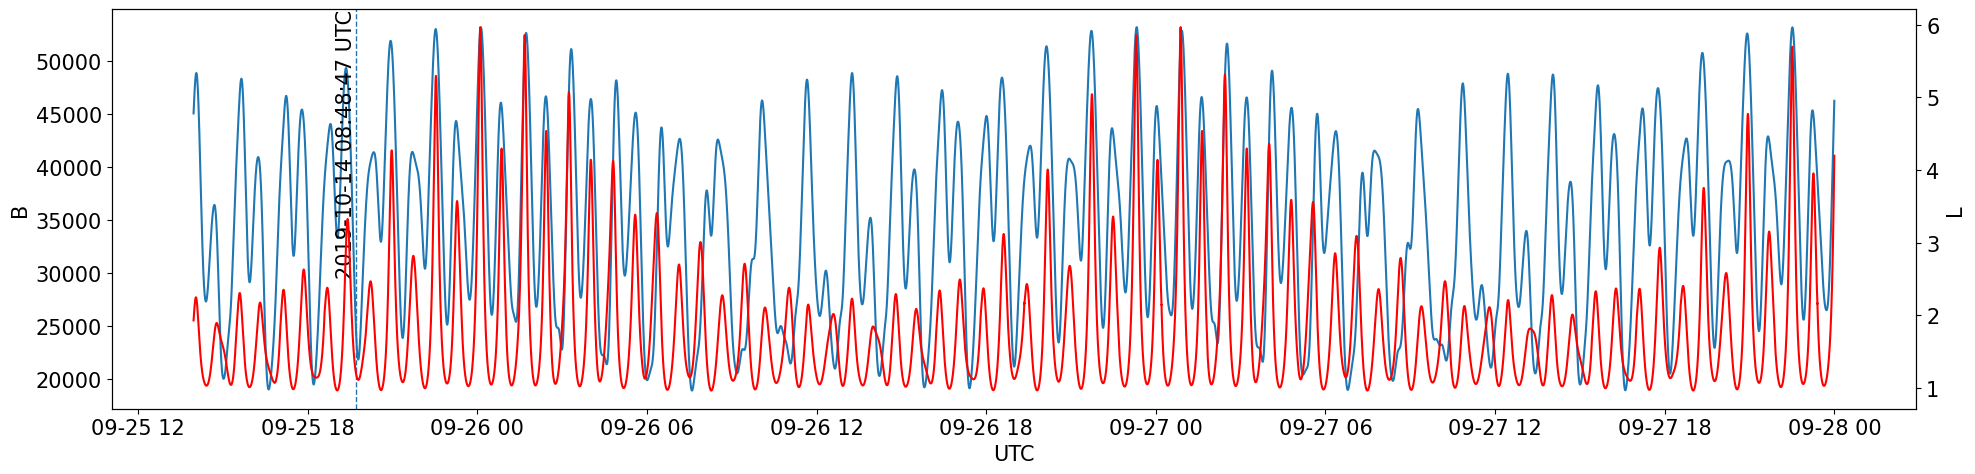

In [5]:
# --- zoom window ---
tmin = pd.Timestamp("2019-09-24 00:00:00", tz="UTC")   # from
tmax = pd.Timestamp("2019-09-28 00:00:00", tz="UTC")   # to
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]

# --- Docking time ---
mark_t = pd.Timestamp("2019-09-25 19:42:40", tz="UTC")

plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["B"], label="B")
ax1.set_xlabel("UTC")
ax1.set_ylabel("B")

ax1.axvline(mark_t, linestyle="--", linewidth=1)
ax1.text(mark_t, ax1.get_ylim()[1], "2019-10-14 08:48:47 UTC",
         rotation=90, va="top", ha="right")

ax2 = ax1.twinx()
ax2.plot(zoom["UTC"], zoom["L"], color="red", label="L")
ax2.set_ylabel("L")

plt.tight_layout()
plt.show()


## Flux

In [6]:
# Copy data from iss2019.csv to temporary file
file_id = "1FHwQdUYfD9M82eCjbk7ApgJi3VtE5sz8"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.csv", quiet=True)

'data.csv'

In [7]:
# Read temporary file
rc = pd.read_csv("data.csv", sep=',', header=0, comment='*')#,engine='python' )

rc.reset_index(drop=True, inplace=True)
rc.head()

,measurement,time,flux,original_time
0,53318,3101377,1.0,3101377
1,53319,3101390,1.0,3101390
2,53320,3101403,0.0,3101403
3,53321,3101416,0.0,3101416
4,53322,3101429,3.0,3101429


In [8]:
rc.loc[rc['flux']>10]


,measurement,time,flux,original_time
37432,25214,3590187,23.0,3590187
37433,25215,3590200,28.0,3590200
37434,25216,3590213,16.0,3590213
37435,25217,3590226,17.0,3590226
37436,25218,3590239,20.0,3590239
...,...,...,...,...
817700,19050,15222243,12.0,2337382
817701,19051,15222259,11.0,2337398
817713,19063,15222459,13.0,2337598
817724,19074,15222642,12.0,2337781


In [9]:
rc['time'] = pd.to_numeric(rc['time'], errors='coerce')

# Launch time
ref_seconds = 3_590_187
ref_abs = pd.Timestamp('2019-09-25 13:57:43', tz='UTC')

t0 = ref_abs - pd.to_timedelta(ref_seconds, unit='s')

# time error
k = 1.005  # <-- sem dosaď své zjištěné k

# calculation of absolute time
rc['abs_time'] = ref_abs + pd.to_timedelta((rc['time'] - ref_seconds) * k, unit='s')

Text(0, 0.5, 'Hits per 10 s')

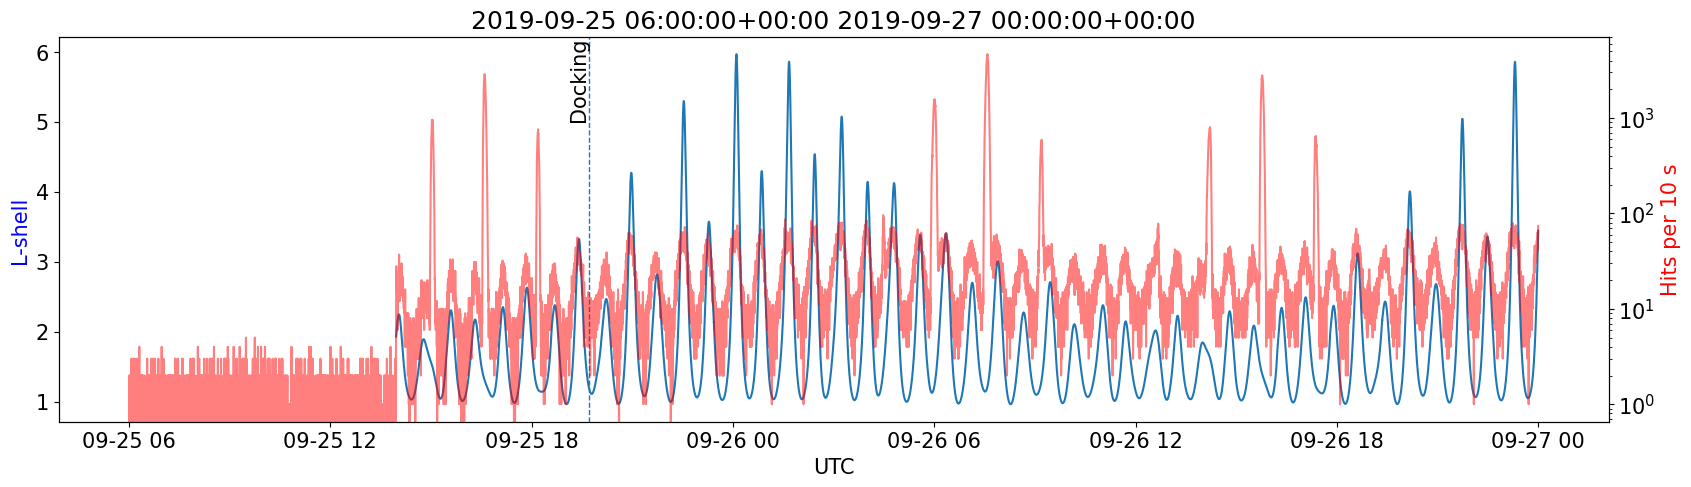

In [10]:
# --- zoom
tmax = pd.Timestamp("2019-09-27 00:00:00", tz="UTC")   # aktuální filtr
tmin = pd.Timestamp("2019-09-25 06:00:00", tz="UTC")   # aktuální filtr
#tmax = pd.Timestamp("2019-10-27 00:00:00", tz="UTC")   # aktuální filtr
#tmin = pd.Timestamp("2019-10-25 06:00:00", tz="UTC")   # aktuální filtr
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]

# --- Docking time
mark_t = pd.Timestamp("2019-09-25 19:42:40", tz="UTC")

plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

ax1.axvline(mark_t, linestyle="--", linewidth=1)
ax1.text(mark_t, ax1.get_ylim()[1], "Docking",
         rotation=90, va="top", ha="right")

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["abs_time"] < tmax].loc[rc["abs_time"] > tmin]
ax2.plot(zoom_data["abs_time"], zoom_data["flux"], label="Flux", color='red', alpha=0.5)
ax2.set_ylabel("Hits per 10 s", color='red')


